# Lección 3 – Preprocesamiento, PCA y t-SNE

En esta lección vamos a preparar los datos de clientes para aplicar técnicas de reducción de dimensionalidad (PCA y t-SNE) y, en lecciones posteriores, algoritmos de clusterización.


## 1. Carga de datos

En esta sección importamos las librerías necesarias y cargamos los archivos `Train.csv` y `Test.csv` en dataframes de pandas.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Carga de datos
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')

train.shape, test.shape

((8068, 11), (2627, 11))

## 2. Vista rápida de los datos

Revisamos las primeras filas del conjunto de entrenamiento para entender la estructura de las columnas y sus valores típicos.


In [3]:
# Primeras filas de Train
train.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


## 3. Tipos de datos y valores nulos

Ahora revisamos los tipos de datos de cada columna y contamos los valores nulos para decidir qué tipo de preprocesamiento aplicar.


In [4]:
# Tipos de datos
dtypes = train.dtypes
print(dtypes)

# Conteo de valores nulos por columna
train.isnull().sum()

ID                   int64
Gender              object
Ever_Married        object
Age                  int64
Graduated           object
Profession          object
Work_Experience    float64
Spending_Score      object
Family_Size        float64
Var_1               object
Segmentation        object
dtype: object


ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64

## 4. Definición de columnas numéricas y categóricas

Separamos las columnas en numéricas y categóricas según su tipo de dato. Esta separación es clave para aplicar transformaciones adecuadas a cada tipo.


In [5]:
numeric_features = []
categorical_features = []

for col, dtype in train.dtypes.items():
    if dtype in ['int64', 'float64']:
        numeric_features.append(col)
    else:
        categorical_features.append(col)

numeric_features, categorical_features

(['ID', 'Age', 'Work_Experience', 'Family_Size'],
 ['Gender',
  'Ever_Married',
  'Graduated',
  'Profession',
  'Spending_Score',
  'Var_1',
  'Segmentation'])

## 5. Pipeline de preprocesamiento

Creamos un pipeline de preprocesamiento que:

1. Imputa y escala las variables numéricas.
2. Imputa y codifica las variables categóricas con OneHotEncoder.

El resultado será una matriz numérica lista para aplicar PCA y t-SNE.


In [6]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Ajuste y transformación de los datos de entrenamiento
X_train_prep = preprocessor.fit_transform(train)
X_train_prep.shape

(8068, 33)

## 6. Aplicación de PCA

Primero aplicamos PCA para analizar cuánta varianza explica cada componente y decidir cuántos componentes conservar.


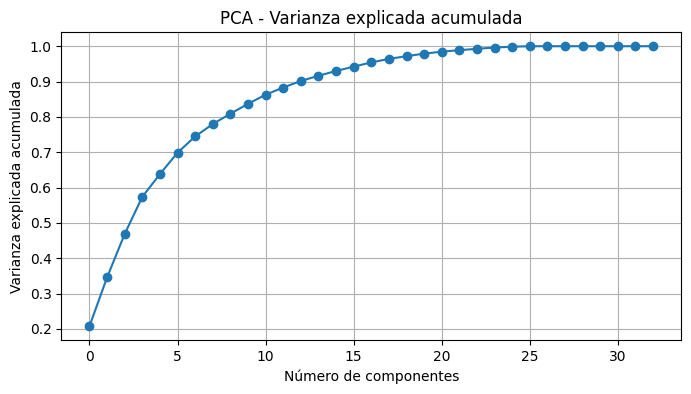

In [7]:
# Si X_train_prep es una matriz dispersa, la convertimos a densa para PCA
X_for_pca = X_train_prep.toarray() if hasattr(X_train_prep, 'toarray') else X_train_prep

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_for_pca)

explained_variance_ratio = pca_full.explained_variance_ratio_

plt.figure(figsize=(8,4))
plt.plot(np.cumsum(explained_variance_ratio), marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - Varianza explicada acumulada')
plt.grid(True)
plt.show()

### 6.1 PCA con 2 componentes

Elegimos 2 componentes principales para visualización y guardamos sus coordenadas.


In [8]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_for_pca)

X_pca_2[:5]

array([[-2.13083365, -0.75359718],
       [ 0.20622766, -0.36053353],
       [ 1.84301363,  0.23787553],
       [ 2.0493703 , -0.31981119],
       [-0.32257446, -1.43155727]])

## 7. Aplicación de t-SNE

Aplicamos t-SNE para obtener una representación en 2D que preserve bien las relaciones locales entre puntos. Para controlar el coste computacional, podemos trabajar con una muestra de los datos.


In [9]:
# Opcional: tomar una muestra si el conjunto es muy grande
n_samples = 2000
if X_train_prep.shape[0] > n_samples:
    from sklearn.utils import resample
    X_sample = resample(X_train_prep, n_samples=n_samples, random_state=42)
else:
    X_sample = X_train_prep

X_for_tsne = X_sample.toarray() if hasattr(X_sample, 'toarray') else X_sample

# t-SNE a 2 dimensiones
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
X_tsne_2 = tsne.fit_transform(X_for_tsne)

X_tsne_2[:5]

array([[-61.09869  ,  -1.3418514],
       [-13.66431  ,  10.552035 ],
       [-20.082146 , -17.593185 ],
       [-65.17973  ,   9.34334  ],
       [ -2.157575 , -19.466736 ]], dtype=float32)

## 8. Resumen y preparación para la clusterización

En esta lección hemos:

1. Cargado y explorado los datos de clientes.
2. Definido y aplicado un pipeline de preprocesamiento para variables numéricas y categóricas.
3. Calculado una representación reducida con PCA (incluyendo una versión de 2 componentes).
4. Calculado una representación en 2D usando t-SNE.

En la siguiente lección aplicaremos K-Means, DBSCAN y agrupamiento jerárquico sobre estas representaciones para construir segmentos de clientes.
